# 1. Business Understanding

## Project: Automated Warning System for Prohibited Minecraft Skins

This project explores whether a machine-learning model can help Minecraft server moderation teams
detect player skins that violate server rules **the moment a player joins the server**, rather than
relying on after-the-fact reports.

---

## 1.1 Background

Minecraft is the **best-selling video game in history** and one of the most heavily modded games on
the market. Beyond the vanilla game, a large ecosystem of community-run servers (Spigot, Paper,
Bukkit, Forge) hosts millions of concurrent players. These servers range from small private worlds
to commercial networks with tens of thousands of daily players.

Every player joining a server brings a **custom skin**: a 64×64 RGBA PNG texture that maps onto the
in-game character model. Skins are freely editable by players and are the most visible form of
self-expression in the game.

This freedom also creates a problem. On most large public servers, certain skin categories are
**explicitly prohibited** by the rules of conduct:

- Sexual / NSFW content
- Hate symbols and politically extremist imagery
- Harassment skins targeting other players or staff

Today, enforcement of these rules relies almost entirely on **manual moderation**: human moderators
review reports submitted by other players, occasionally spot-check players on the server, and ban
offenders after the fact. This approach has well-known weaknesses:

- A prohibited skin is visible to every other player **before** any moderator sees it.
- Moderation teams on busy servers are chronically understaffed.
- Reports are noisy (used as a harassment vector, or never submitted at all).
- New players cycling in faster than moderators can review them.

We could not find an existing publicly deployed solution to this specific problem, although the
need is well-attested by the prevalence of skin-related bans on community servers.

---

## 1.2 Business Problem

> **Can a model give a Minecraft server moderation team an automated, real-time risk score for every
> incoming player skin, so that they can focus their limited human attention on the players most
> likely to be in violation of the server's rules?**

The model is **not** intended to issue automated bans. Skin policies are highly server-specific,
context-dependent, and frequently contested by players. Auto-banning on a model prediction would be
both technically premature (residual false-positive rate is too high) and operationally unwise
(moderators must retain final authority).

Instead, the model is positioned as a **decision-support tool**:

- A new player joins the server.
- Within milliseconds, the model scores their skin.
- If the score exceeds a server-configurable threshold, the moderation team is notified in-game
  (chat, dashboard, Discord webhook — depending on the plugin).
- A human moderator reviews the flagged skin and decides whether to act.

This is a textbook **human-in-the-loop** moderation system.

---

## 1.3 Project Scope and the "Spider-Man Proxy"

A fully production-grade version of this system would be trained on the actual prohibited classes
listed above (NSFW, hate symbols, etc.). For an academic project at FH, training on such material
is **explicitly out of scope** — both ethically (we will not collect and label NSFW or extremist
imagery for this academic showcase) and legally (e.g. Verbotsgesetz).

We therefore picked a **proxy class** that shares the *structural properties* of the real problem
but is academically and ethically clean:

> **Copyrighted character skins, exemplified by Spider-Man.**

Why this works as a proxy:

1. **It is also prohibited** on many large servers, so the use case is not synthetic.
2. **Visually coherent target.** Spider-Man skins share a strong set of features
   (red-and-blue color palette, spider-icon torso, characteristic eye pattern, webbing texture)
   that the model can learn from a few thousand examples — analogous to how real prohibited
   categories cluster visually.
3. **Cleanly scrapable** by keyword from `minecraftskins.com`. We could just as easily scrape
   `bikini`, `military`, `nazi`, `swastika` (and we did experiment with `bikini` and `ww2`), but
   we chose Spider-Man as the headline class to keep the project family-friendly.
4. **The same pipeline transfers.** Our keyword scraper, cleaning workflow, CNN architecture,
   threshold-tuning strategy, and FastAPI deployment would all be reused unchanged for
   real prohibited classes. Only the training data changes.

The intellectual contribution of this project is **the pipeline and the deployment story**, not the
specific class label. We are aware that detecting Spider-Man specifically has no commercial value;
detecting *whatever prohibited concept a server cares about*, given a few thousand example skins,
is the actual product.

---

## 1.4 Success Criteria

### Business success criterion

A moderator wearing a pager does not mind a few false alarms — they *do* mind missing a serious
violation. **Missing a prohibited skin (false negative) is much more costly than flagging an
innocent player (false positive)**, because:

- A false positive costs ~30 seconds of a moderator's time to dismiss.
- A false negative leaves a prohibited skin visible to every other player, possibly for hours,
  with reputational damage to the server.

Therefore the model is optimized for **recall**, not for accuracy or F1.

### Technical success criterion

- **Primary metric:** Recall ≥ 0.95 on a test set.
- **Constraint:** Precision must be substantially higher than the random-guess baseline at the
  same recall, otherwise the moderator queue is flooded.
- **Operating point:** A decision threshold is tuned on the validation set to hit the recall
  target with the strictest possible precision. The threshold is exposed in deployment as a
  configurable parameter, so individual server admins can dial recall up or down based on
  how much moderator attention they have available.

### Project success criterion

- Cover all six phases of the CRISP-DM lifecycle.
- Provide at least one baseline (we provide two: majority-class and PCA + LogisticRegression).
- Demonstrate a defensible model selection and tuning strategy.
- Deliver a working deployment artifact (REST API) that an actual Minecraft server plugin could
  call on a player-join event.

---

## 1.5 Stakeholders

| Role | Interest |
|---|---|
| **Server admins / owners** | Want low-friction moderation that doesn't require hiring more humans. |
| **Moderators** | Want their attention directed only at likely violations, not random reports. |
| **Players** | Want a fair, transparent rule-enforcement system — not opaque AI bans. |
| **Plugin developers** | Want a simple, well-documented REST endpoint they can call from Spigot/Paper. |

The system explicitly does **not** target end-players or replace any existing reporting mechanism.

---

## 1.6 Risks and Limitations

| Risk                                                                           | Mitigation in this project |
|--------------------------------------------------------------------------------|---|
| **Label noise in the "good" class** (random players may wear Spider-Man skins) | Manual cleaning pass: confidently-mislabeled examples moved between classes (see Data Preparation). |
| **Imbalanced classes** (~9:1)                                                  | Class-weighted loss + recall-targeted threshold tuning. |
| **Single proxy class ≠ production**                                            | Acknowledged; pipeline designed to generalize. Marked as future work. |
| **Mojang API rate limits** in deployment                                       | API caching + skin-hash short-circuit (future work). |
| **Adversarial players** modifying skins to evade the classifier                | Out of scope |
| **False bans destroy trust**                                                   | System never bans automatically; only raises a warning. |

---

## 1.7 Out of Scope

- Automated banning or any form of player punishment.
- Detecting prohibited *behaviour* (chat, builds) — only skin imagery.
- Multi-class classification across all prohibited categories. This work is binary
  (Spider-Man vs. not Spider-Man); generalization to N classes would be an extension
- Training on real prohibited categories (NSFW, hate, political) — see Section 1.3.


Skins and online Editor https://www.minecraftskins.net

In [5]:
from collections import Counter
sizes = Counter()
for p in list(GOOD_DIR.glob("*.png")) + list(BAD_DIR.glob("*.png")):
    img = Image.open(p)
    sizes[img.size] += 1
print("sizes:", sizes)

sizes: Counter({(64, 64): 10000})


In [6]:
# Mean image per class — gives a first hint about what the model can learn
def mean_image(folder):
    arrs = [np.asarray(Image.open(p).convert("RGBA")) / 255.0
            for p in folder.glob("*.png")]
    return np.mean(arrs, axis=0)


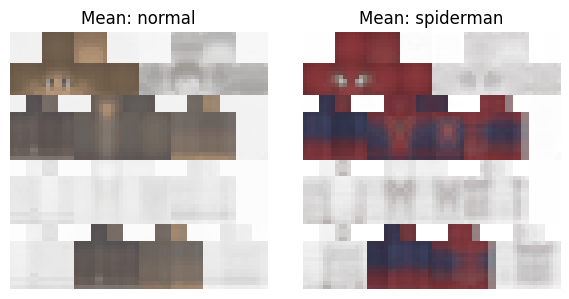

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(mean_image(GOOD_DIR)); ax[0].set_title("Mean: normal")
ax[1].imshow(mean_image(BAD_DIR));  ax[1].set_title("Mean: spiderman")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

The mean Spider-Man skin will have a visibly red-and-blue color distribution. The classes are visually separable on color statistics alone but the spiderman dataset also has different colored versions

---

## 2.6 3D skin view tool

A standalone helper script `01_BusinessUnderstanding/skin.py` renders any 64×64 skin file as a
rotating 3D Minecraft character using only `matplotlib`. Sadly we couldn't use it in the later phases but it would be helpful for a future active learning pipeline

```powershell
python 02_DataUnderstanding/skin.py
```

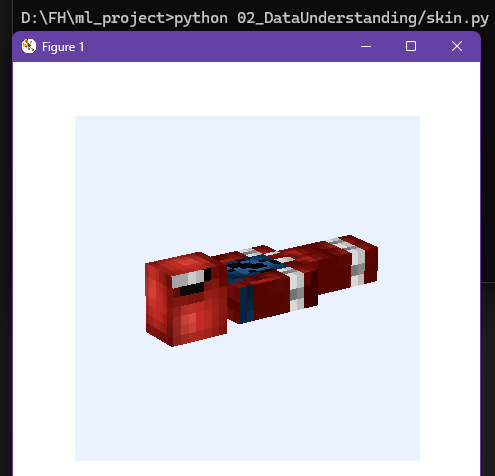

## 2.7 Summary

- Skins are 64×64, UV-unwrapped, with the alpha channel acting as a structural mask.
- Negative class (9k) comes from a Kaggle dataset of real Mojang-API-sourced player skins.
- Positive class (1k) is the Cloudflare-aware keyword scrape of `minecraftskins.com`.
- Imbalance is 9:1; manageable with class weights and threshold tuning.
- Label noise lives in the negative class and is *informative* — strong CNN false-positives.